# Calculate contours based on DEM

In [8]:
from dask import delayed
from dask import compute
from pathlib import Path
from xrspatial import contours
import numpy as np
import rioxarray  
import time
import xarray as xr

Define process to handle one file.

In [2]:
def processFile(file_path):
    print(f"\n{file_path} started")
    # Open file with xarray
    dem = xr.open_dataarray(file_path, engine="rasterio")
    
    # Xarray adds third dimension, drop it.
    dem = dem.squeeze("band", drop=True)   
    
    # Calculate contours
    lines = contours(dem, levels=np.arange(0, 1300, 100), return_type="geopandas")
    
    # Save output file
    output_filename = Path(file_path).stem + ".gpkg"
    lines.to_file(output_filename, driver="GPKG")
    
    print(f"{file_path} done")

Use for-loop to go trhough all files, one after another.

In [5]:
with open("mapsheets_URLs.txt") as f:
    files = [line.strip() for line in f if line.strip()]
    for file in files:
        processFile(file)


 /vsicurl/https://www.nic.funet.fi/index/geodata/mml/dem10m/2019/W3/W33/W3333.tif started
/vsicurl/https://www.nic.funet.fi/index/geodata/mml/dem10m/2019/W3/W33/W3333.tif done

 /vsicurl/https://www.nic.funet.fi/index/geodata/mml/dem10m/2019/W3/W33/W3332.tif started
/vsicurl/https://www.nic.funet.fi/index/geodata/mml/dem10m/2019/W3/W33/W3332.tif done

 /vsicurl/https://www.nic.funet.fi/index/geodata/mml/dem10m/2019/W3/W33/W3331.tif started
/vsicurl/https://www.nic.funet.fi/index/geodata/mml/dem10m/2019/W3/W33/W3331.tif done


Plot one of the files, to see the result.

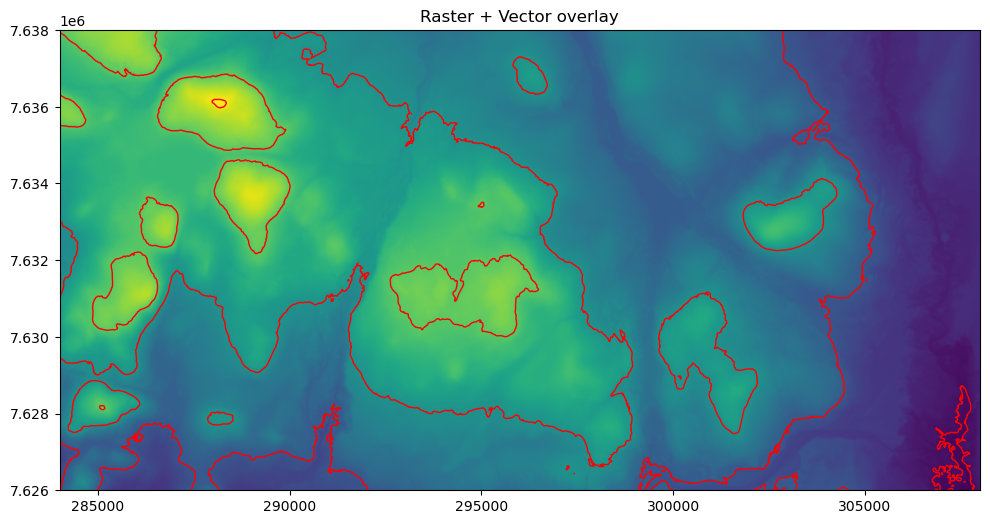

In [14]:
import rasterio
import rasterio.plot
import geopandas as gpd
import matplotlib.pyplot as plt

tif_path = "/vsicurl/https://www.nic.funet.fi/index/geodata/mml/dem10m/2019/W3/W33/W3333.tif"
gpkg_path = "W3333.gpkg"

# Load vector
gdf = gpd.read_file(gpkg_path)

# Plot
fig, ax = plt.subplots(figsize=(10, 10))

with rasterio.open(tif_path) as src:
    # Reproject vector to match raster CRS if needed
    gdf = gdf.to_crs(src.crs)
    rasterio.plot.show(src, ax=ax)

gdf.plot(ax=ax, facecolor="none", edgecolor="red", linewidth=1)

plt.title("Raster + Vector overlay")
plt.tight_layout()
plt.show()    